# 04 — Pricing Policy Evaluation and Baseline Comparison

This final notebook evaluates fixed, rule-based, and RL pricing on exactly the same held-out test markets. It compares total expected revenue, average penalized reward, retained demand, and average selected multiplier.

Run notebooks 01–03 first.

## 1. Load test data and learned artifacts

In [1]:
from pathlib import Path
import json
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dynamic_pricing.csv').exists() and (PROJECT_ROOT.parent / 'dynamic_pricing.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'Project root: {PROJECT_ROOT.resolve()}')

Project root: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Artificial Intellegence Driven Decision Making\CA2 Project


In [2]:
required = [
    'test_features.csv', 'test_environment_costs.csv',
    'model_metrics.csv', 'q_learning_artifacts.joblib',
    'training_rewards.csv'
]
missing = [name for name in required if not (ARTIFACT_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Run notebooks 01–03 first. Missing: {missing}')

X_test = pd.read_csv(ARTIFACT_DIR / 'test_features.csv')
test_costs = pd.read_csv(ARTIFACT_DIR / 'test_environment_costs.csv')
test_base_cost = test_costs['predicted_base_cost'].to_numpy()
model_metrics = pd.read_csv(ARTIFACT_DIR / 'model_metrics.csv')
training_rewards = pd.read_csv(ARTIFACT_DIR / 'training_rewards.csv')
rl_artifacts = joblib.load(ARTIFACT_DIR / 'q_learning_artifacts.joblib')

print(f'Test markets: {len(X_test)}')
display(model_metrics.style.format({'value': '{:,.3f}'}))

Test markets: 200


,metric,value
0,MAE,55.578
1,RMSE,74.427
2,R2,0.848


## 2. Reconstruct the environment and discrete state mapping

In [3]:
ACTIONS = rl_artifacts['actions']
PRICE_ELASTICITY = rl_artifacts['price_elasticity']
EXCESS_PENALTY_WEIGHT = rl_artifacts['excess_penalty_weight']
q_table = rl_artifacts['q_table']
fallback_action = rl_artifacts['fallback_action']
bin_edges = rl_artifacts['bin_edges']
category_maps = rl_artifacts['category_maps']
state_numeric_columns = rl_artifacts['state_numeric_columns']
categorical_columns = rl_artifacts['categorical_columns']

def pricing_outcome(base_cost, multiplier, demand_supply_ratio):
    adjusted_price = float(base_cost) * float(multiplier)
    pressure = float(np.clip(demand_supply_ratio, 0.5, 3.0))
    local_elasticity = PRICE_ELASTICITY / np.sqrt(pressure)
    retained_demand = np.exp(-local_elasticity * (float(multiplier) - 1.0))
    retained_demand = float(np.clip(retained_demand, 0.45, 1.10))
    expected_revenue = adjusted_price * retained_demand
    excess = max(0.0, float(multiplier) - 1.10)
    penalty = float(base_cost) * EXCESS_PENALTY_WEIGHT * (excess ** 2)
    reward = expected_revenue - penalty
    return adjusted_price, retained_demand, expected_revenue, penalty, reward

def row_to_state(row):
    numeric_state = tuple(
        int(np.digitize(float(row[column]), bin_edges[column]))
        for column in state_numeric_columns
    )
    categorical_state = tuple(
        category_maps[column].get(row[column], -1)
        for column in categorical_columns
    )
    return numeric_state + categorical_state

test_states = [row_to_state(row) for _, row in X_test.iterrows()]
known_test_states = sum(state in q_table for state in test_states)
print(f'Known test states: {known_test_states}/{len(test_states)}')
print(f'Unseen-state fallback multiplier: {ACTIONS[fallback_action]:.1f}')

Known test states: 35/200
Unseen-state fallback multiplier: 1.1


 ## 3. Define comparison policies

- **Fixed pricing:** always selects 1.0.
- **Rule-based pricing:** raises price when demand exceeds supply and discounts when demand is low.
- **RL pricing:** chooses the action with the highest learned Q-value for the discretized state. Unseen states use the best global learned action.

In [4]:
def fixed_policy(row, state):
    return 1.0

def rule_based_policy(row, state):
    ratio = row['demand_supply_ratio']
    if ratio > 1.50:
        return 1.2
    if ratio > 1.10:
        return 1.1
    if ratio < 0.80:
        return 0.9
    return 1.0

def rl_policy(row, state):
    if state in q_table and not np.allclose(q_table[state], 0):
        action = int(np.argmax(q_table[state]))
    else:
        action = int(fallback_action)
    return float(ACTIONS[action])

## 4. Evaluate all policies on the held-out test set

In [5]:
def evaluate_policy(name, policy):
    records = []
    for (_, row), state, base_cost in zip(
        X_test.iterrows(), test_states, test_base_cost
    ):
        multiplier = policy(row, state)
        adjusted_price, retained, revenue, penalty, reward = pricing_outcome(
            base_cost, multiplier, row['demand_supply_ratio']
        )
        records.append({
            'method': name,
            'base_cost': base_cost,
            'multiplier': multiplier,
            'adjusted_price': adjusted_price,
            'retained_demand': retained,
            'expected_revenue': revenue,
            'penalty': penalty,
            'reward': reward
        })
    return pd.DataFrame(records)

policy_results = pd.concat([
    evaluate_policy('Fixed pricing', fixed_policy),
    evaluate_policy('Rule-based pricing', rule_based_policy),
    evaluate_policy('RL pricing', rl_policy)
], ignore_index=True)

comparison = (policy_results.groupby('method', sort=False)
              .agg(total_revenue=('expected_revenue', 'sum'),
                   average_reward=('reward', 'mean'),
                   average_multiplier=('multiplier', 'mean'),
                   average_retained_demand=('retained_demand', 'mean'))
              .reset_index())

display(comparison.style.format({
    'total_revenue': '{:,.2f}',
    'average_reward': '{:,.2f}',
    'average_multiplier': '{:.3f}',
    'average_retained_demand': '{:.3f}'
}))

policy_results.to_csv(ARTIFACT_DIR / 'policy_level_results.csv', index=False)
comparison.to_csv(ARTIFACT_DIR / 'policy_comparison.csv', index=False)

,method,total_revenue,average_reward,average_multiplier,average_retained_demand
0,Fixed pricing,"77,760.41",388.80,1.000,1.000
1,Rule-based pricing,"78,041.03",364.24,1.183,0.849
2,RL pricing,"77,728.37",386.36,1.084,0.925


## 5. Visualisations

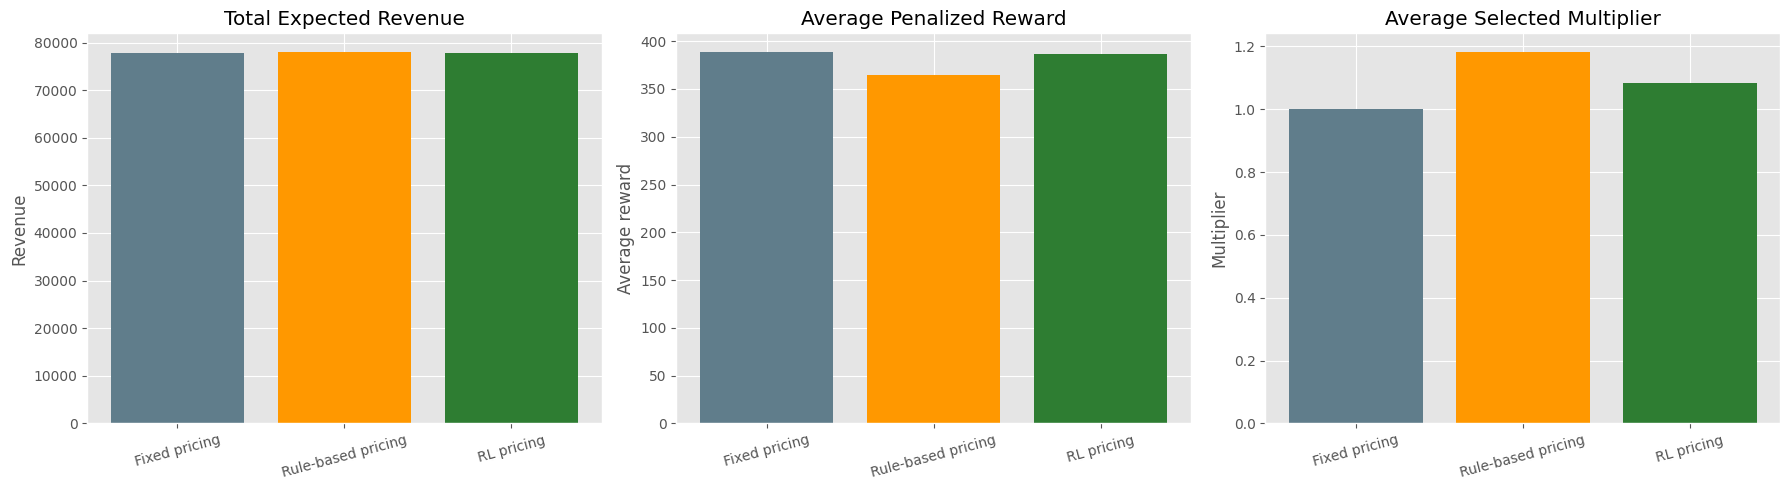

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#607D8B', '#FF9800', '#2E7D32']
methods = comparison['method'].tolist()

axes[0].bar(methods, comparison['total_revenue'], color=colors)
axes[0].set_title('Total Expected Revenue')
axes[0].set_ylabel('Revenue')

axes[1].bar(methods, comparison['average_reward'], color=colors)
axes[1].set_title('Average Penalized Reward')
axes[1].set_ylabel('Average reward')

axes[2].bar(methods, comparison['average_multiplier'], color=colors)
axes[2].set_title('Average Selected Multiplier')
axes[2].set_ylabel('Multiplier')

for axis in axes:
    axis.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

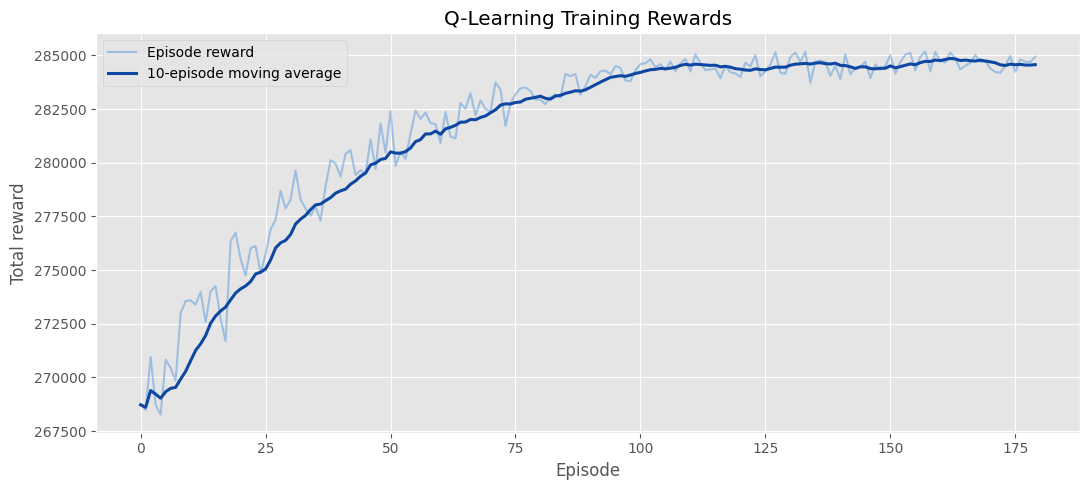

In [7]:
plt.figure(figsize=(11, 5))
plt.plot(training_rewards['total_reward'], alpha=0.35,
         color='#1976D2', label='Episode reward')
plt.plot(training_rewards['moving_average_10'], color='#0D47A1',
         linewidth=2.2, label='10-episode moving average')
plt.title('Q-Learning Training Rewards')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Final summary

Gross revenue and reward are intentionally reported separately. Reward includes the excessive-price penalty, so the method with the highest revenue may not have the highest business-policy score.

In [8]:
metrics_map = dict(zip(model_metrics['metric'], model_metrics['value']))
best_revenue = comparison.loc[comparison['total_revenue'].idxmax()]
best_reward = comparison.loc[comparison['average_reward'].idxmax()]

print('=' * 76)
print('FINAL DYNAMIC PRICING EVALUATION')
print('=' * 76)
print(f"Random Forest MAE:  {metrics_map['MAE']:,.2f}")
print(f"Random Forest RMSE: {metrics_map['RMSE']:,.2f}")
print(f"Random Forest R²:   {metrics_map['R2']:.3f}")
print()
for _, result in comparison.iterrows():
    print(
        f"{result['method']:<22} | "
        f"Revenue: {result['total_revenue']:>10,.2f} | "
        f"Avg reward: {result['average_reward']:>8,.2f} | "
        f"Avg multiplier: {result['average_multiplier']:.3f}"
    )
print()
print(
    f"Highest total expected revenue: {best_revenue['method']} "
    f"({best_revenue['total_revenue']:,.2f})."
)
print(
    f"Highest average penalized reward: {best_reward['method']} "
    f"({best_reward['average_reward']:,.2f})."
)

if best_reward['method'] == 'RL pricing':
    print(
        'Conclusion: RL pricing performed best under the defined reward objective, '
        'balancing expected revenue against demand loss and excessive pricing.'
    )
else:
    print(
        f"Conclusion: {best_reward['method']} performed best under the defined "
        'reward objective. This result should guide further tuning of the state '
        'bins, elasticity assumptions, and RL hyperparameters.'
    )

FINAL DYNAMIC PRICING EVALUATION
Random Forest MAE:  55.58
Random Forest RMSE: 74.43
Random Forest R²:   0.848

Fixed pricing          | Revenue:  77,760.41 | Avg reward:   388.80 | Avg multiplier: 1.000
Rule-based pricing     | Revenue:  78,041.03 | Avg reward:   364.24 | Avg multiplier: 1.183
RL pricing             | Revenue:  77,728.37 | Avg reward:   386.36 | Avg multiplier: 1.084

Highest total expected revenue: Rule-based pricing (78,041.03).
Highest average penalized reward: Fixed pricing (388.80).
Conclusion: Fixed pricing performed best under the defined reward objective. This result should guide further tuning of the state bins, elasticity assumptions, and RL hyperparameters.


## Project limitations and extensions

This is a student simulation rather than a production pricing system. Real deployment would require observed booking/conversion responses, causal price-elasticity estimation, fairness and legal constraints, price caps, driver/customer welfare measures, uncertainty analysis, and repeated evaluation across random seeds.